Fabian Prado Dluzniewski 23427
# Laboratorio 2 — Deep Learning (LSTM)

## Ejercicio 1. Modelos LSTM para las series de País (Top 3)

Se reutilizan las series y los conjuntos de entrenamiento/prueba del
Laboratorio 1: base comparable **Turista + Excursionista**, agregación
mensual, ventana común **2009-01 a 2022-12** para País (desde 2023 la
fuente migra de país a agrupaciones de mercado) y división temporal
70/30 sin barajar.

### IMPORTS

In [1]:
import os
import random
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")

DISPOSITIVO = torch.device("cpu")   # ~105 ventanas: la GPU sería puro overhead
SEMILLAS = [42, 7]
VAL_MESES = 24
PACIENCIA = 30

def fijar_semilla(semilla):
    os.environ["PYTHONHASHSEED"] = str(semilla)
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)

### LECTURA DE DATOS

In [3]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")

df_ts = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()
df_ts["Fecha"] = pd.to_datetime(
    dict(year=df_ts["Año"], month=df_ts["Mes cod"], day=1)
)
calendario = pd.date_range(df_ts["Fecha"].min(), df_ts["Fecha"].max(), freq="MS")

def serie_mensual(datos, filtro_col=None, filtro_val=None):
    subset = datos if filtro_col is None else datos[datos[filtro_col] == filtro_val]
    return (
        subset.groupby("Fecha")["Viajero"].sum()
        .reindex(calendario, fill_value=0)
        .astype(float)
        .asfreq("MS")
    )

def dividir_serie(serie, proporcion=0.70):
    corte = int(np.floor(len(serie) * proporcion))
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()

top3_paises = (
    df_ts[df_ts["Año"] <= 2022]
    .groupby("País")["Viajero"].sum().nlargest(3).index.tolist()
)
series_paises = {
    pais: serie_mensual(df_ts, "País", pais).loc[:"2022-12-01"]
    for pais in top3_paises
}
divisiones = {pais: dividir_serie(s) for pais, s in series_paises.items()}

print("Top 3 países (mismos del Laboratorio 1):", ", ".join(top3_paises))

Top 3 países (mismos del Laboratorio 1): Guatemala, El Salvador, Estados Unidos de América


## 1.1. Conjuntos de entrenamiento y prueba

La división es exactamente la del Laboratorio 1 (70/30 temporal). El
conjunto de prueba de cada país abarca 51 meses e incluye completo el
choque de 2020, por lo que cualquier modelo evaluado aquí enfrenta un
horizonte largo con un cambio estructural dentro. Esto es deliberado:
mantener la misma partición es la única forma de comparar LSTM contra
los modelos clásicos del laboratorio anterior.

In [4]:
resumen_division = pd.DataFrame([
    {
        "Serie": pais,
        "Inicio": s.index.min(),
        "Fin": s.index.max(),
        "Meses": len(s),
        "n_train": len(divisiones[pais][0]),
        "n_test": len(divisiones[pais][1]),
        "Inicio prueba": divisiones[pais][1].index.min(),
        "Promedio prueba": divisiones[pais][1].mean(),
    }
    for pais, s in series_paises.items()
])
display(resumen_division.style.format({"Promedio prueba": "{:,.0f}"}))

,Serie,Inicio,Fin,Meses,n_train,n_test,Inicio prueba,Promedio prueba
0,Guatemala,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"88,013"
1,El Salvador,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"50,298"
2,Estados Unidos de América,2009-01-01 00:00:00,2022-12-01 00:00:00,168,117,51,2018-10-01 00:00:00,"26,849"


## 1.2. Preprocesamiento y diseño de los modelos

**Escala.** Se aplica `log1p` (admite ceros, amortigua el choque de 2020 y
evita pronósticos negativos al invertir) y luego `MinMaxScaler` a [0,1].
El escalador se **ajusta únicamente con entrenamiento** para no filtrar
información del futuro.

**Ventanas.** Cada observación se convierte en un par (ventana de
`lookback` meses → siguiente valor o siguientes `h` valores). Con
`lookback = 12` la red puede aprender el ciclo anual completo.

**Dos arquitecturas por serie:**

| | Modelo A — LSTM recursiva | Modelo B — LSTM directa multi-horizonte |
|---|---|---|
| Salida | 1 paso (`Dense(1)`) | `h` pasos (`Dense(h)`) |
| Pronóstico | realimenta su propia predicción | una sola pasada |
| Riesgo | acumulación de error | menos ventanas de entrenamiento |

**Tuneo.** Los últimos 24 meses del entrenamiento se reservan como
validación interna; se pronostican de forma recursiva/directa igual que
en prueba y se selecciona por RMSE. Cada configuración se entrena con
2 semillas y se promedia, porque con ~100 ventanas la varianza entre
inicializaciones no es despreciable. **El conjunto de prueba no se toca
durante el tuneo.**

In [5]:
def preparar_escalador(train):
    escalador = MinMaxScaler(feature_range=(0, 1))
    escalador.fit(np.log1p(train.to_numpy(dtype=float)).reshape(-1, 1))
    return escalador

def escalar(valores, escalador):
    log_vals = np.log1p(np.asarray(valores, dtype=float)).reshape(-1, 1)
    return escalador.transform(log_vals).ravel()

def desescalar(valores_escalados, escalador):
    log_vals = escalador.inverse_transform(
        np.asarray(valores_escalados, dtype=float).reshape(-1, 1)
    ).ravel()
    return np.maximum(0.0, np.expm1(log_vals))

def crear_ventanas(serie_escalada, lookback, horizonte=1):
    X, y = [], []
    for i in range(len(serie_escalada) - lookback - horizonte + 1):
        X.append(serie_escalada[i:i + lookback])
        y.append(serie_escalada[i + lookback:i + lookback + horizonte])
    if not X:
        return np.empty((0, lookback, 1)), np.empty((0, horizonte))
    return (
        np.asarray(X, dtype="float32").reshape(-1, lookback, 1),
        np.asarray(y, dtype="float32").reshape(-1, horizonte),
    )

def pronostico_recursivo(modelo, ventana_inicial, pasos):
    lookback = len(ventana_inicial)
    ventana = list(np.asarray(ventana_inicial, dtype="float32"))
    predicciones = []
    modelo.eval()
    with torch.no_grad():
        for _ in range(pasos):
            entrada = torch.tensor(
                np.asarray(ventana[-lookback:], dtype="float32").reshape(1, lookback, 1)
            )
            siguiente = float(modelo(entrada).numpy().ravel()[0])
            predicciones.append(siguiente)
            ventana.append(siguiente)
    return np.asarray(predicciones)

def metricas(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_real, y_pred))),
    }

In [6]:
class RedLSTM(nn.Module):
    """LSTM apilada; `salida=1` para la variante recursiva, `salida=h` para la directa."""
    def __init__(self, unidades, capas, dropout, salida):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=unidades, num_layers=capas,
            batch_first=True, dropout=dropout if capas > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(unidades, salida)

    def forward(self, x):
        salidas, _ = self.lstm(x)
        return self.fc(self.dropout(salidas[:, -1, :]))


class Historia:
    """Imita el objeto History de Keras para que el Lego 11 no cambie."""
    def __init__(self, registro):
        self.history = registro

In [7]:
def entrenar_y_pronosticar(train, config, horizonte, semilla, verbose=0):
    """Ajusta con `train` y devuelve `horizonte` predicciones en escala original."""
    fijar_semilla(semilla)
    lookback = config["lookback"]
    escalador = preparar_escalador(train)
    y_esc = escalar(train.to_numpy(), escalador)

    salida = 1 if config["arquitectura"] == "recursiva" else horizonte
    X, y = crear_ventanas(y_esc, lookback, salida)
    if len(X) < 12:
        return None, None, None

    # División interna 85/15 sin barajar: equivale al validation_split de Keras
    corte = int(len(X) * 0.85)
    X_tr, y_tr = torch.tensor(X[:corte]), torch.tensor(y[:corte])
    X_va, y_va = torch.tensor(X[corte:]), torch.tensor(y[corte:])

    modelo = RedLSTM(config["unidades"], config["capas"], config["dropout"], salida)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["lr"])
    perdida_fn = nn.MSELoss()

    registro = {"loss": [], "val_loss": []}
    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    n, batch = len(X_tr), config["batch"]

    for epoca in range(config["epochs"]):
        modelo.train()
        acumulado = 0.0
        for i in range(0, n, batch):
            xb, yb = X_tr[i:i + batch], y_tr[i:i + batch]
            optimizador.zero_grad()
            perdida = perdida_fn(modelo(xb), yb)
            perdida.backward()
            optimizador.step()
            acumulado += perdida.item() * len(xb)

        modelo.eval()
        with torch.no_grad():
            val = perdida_fn(modelo(X_va), y_va).item()

        registro["loss"].append(acumulado / n)
        registro["val_loss"].append(val)

        # Early stopping con restauración de los mejores pesos
        if val < mejor_val - 1e-6:
            mejor_val, sin_mejora = val, 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA:
                break
        if verbose and epoca % 50 == 0:
            print(f"  época {epoca}: train={registro['loss'][-1]:.5f} val={val:.5f}")

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    modelo.eval()
    with torch.no_grad():
        if config["arquitectura"] == "recursiva":
            pred_esc = pronostico_recursivo(modelo, y_esc[-lookback:], horizonte)
        else:
            entrada = torch.tensor(
                y_esc[-lookback:].reshape(1, lookback, 1).astype("float32")
            )
            pred_esc = modelo(entrada).numpy().ravel()

    return desescalar(pred_esc, escalador), modelo, Historia(registro)

In [8]:
def cfg(arquitectura, lookback, unidades, capas, dropout, lr=1e-3, epochs=400, batch=8):
    return {
        "arquitectura": arquitectura, "lookback": lookback, "unidades": unidades,
        "capas": capas, "dropout": dropout, "lr": lr, "epochs": epochs, "batch": batch,
    }

CONFIGS_A = [   # Modelo A: LSTM recursiva (salida de 1 paso)
    cfg("recursiva", 12, 32, 1, 0.0),
    cfg("recursiva", 12, 64, 1, 0.1),
    cfg("recursiva", 12, 32, 2, 0.2),
    cfg("recursiva", 24, 32, 1, 0.0),
    cfg("recursiva", 24, 64, 2, 0.2),
    cfg("recursiva", 12, 64, 1, 0.1, lr=5e-4),
]

CONFIGS_B = [   # Modelo B: LSTM directa multi-horizonte (salida de h pasos)
    cfg("directa", 12, 32, 1, 0.0),
    cfg("directa", 12, 64, 1, 0.1),
    cfg("directa", 12, 64, 2, 0.2),
    cfg("directa", 24, 32, 1, 0.1),
    cfg("directa", 24, 64, 1, 0.2),
    cfg("directa", 12, 128, 1, 0.2, lr=5e-4),
]

def etiqueta(config):
    return (f"{config['arquitectura']}|lb={config['lookback']}|u={config['unidades']}"
            f"|capas={config['capas']}|drop={config['dropout']}|lr={config['lr']:g}")

print(f"{len(CONFIGS_A)} configuraciones A + {len(CONFIGS_B)} configuraciones B "
      f"× {len(SEMILLAS)} semillas × {len(series_paises)} series = "
      f"{(len(CONFIGS_A)+len(CONFIGS_B))*len(SEMILLAS)*len(series_paises)} ajustes")

6 configuraciones A + 6 configuraciones B × 2 semillas × 3 series = 72 ajustes


In [9]:
def tunear(train, configs, horizonte_val=VAL_MESES, semillas=SEMILLAS):
    sub_train = train.iloc[:-horizonte_val]
    sub_val = train.iloc[-horizonte_val:]
    filas = []
    for config in configs:
        rmses, maes = [], []
        for semilla in semillas:
            pred, _, _ = entrenar_y_pronosticar(sub_train, config, horizonte_val, semilla)
            if pred is None:
                break
            m = metricas(sub_val.to_numpy(), pred)
            rmses.append(m["RMSE"]); maes.append(m["MAE"])
        if not rmses:
            continue
        filas.append({
            "Arquitectura": "A. Recursiva" if config["arquitectura"] == "recursiva" else "B. Directa",
            "Configuración": etiqueta(config),
            "MAE_val": float(np.mean(maes)),
            "RMSE_val": float(np.mean(rmses)),
            "RMSE_sd": float(np.std(rmses)),
            "_config": config,
        })
    return pd.DataFrame(filas).sort_values("RMSE_val").reset_index(drop=True)

tuneos = {}
for pais, (train, test) in divisiones.items():
    print(f"\n=== Tuneando {pais} ===")
    tabla = pd.concat(
        [tunear(train, CONFIGS_A), tunear(train, CONFIGS_B)],
        ignore_index=True,
    ).sort_values(["Arquitectura", "RMSE_val"]).reset_index(drop=True)
    tuneos[pais] = tabla
    display(
        tabla.drop(columns="_config").style.format(
            {"MAE_val": "{:,.0f}", "RMSE_val": "{:,.0f}", "RMSE_sd": "{:,.0f}"}
        ).set_caption(f"Tuneo — {pais} (validación: últimos {VAL_MESES} meses de train)")
    )


=== Tuneando Guatemala ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"17,005","23,388",640
1,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"17,140","23,465",406
2,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"18,159","25,331",362
3,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"19,315","25,997","4,363"
4,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"20,271","27,079",618
5,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"20,627","27,238","2,585"
6,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"30,238","35,488","1,381"
7,B. Directa,directa|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"32,332","37,541","5,955"
8,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"31,781","39,372","3,265"
9,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"35,625","42,242","2,720"



=== Tuneando El Salvador ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"18,396","25,804","1,774"
1,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"18,372","25,890",603
2,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"18,931","26,475","1,425"
3,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"21,451","28,548","4,760"
4,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"21,315","28,707",5
5,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"25,393","32,410",63
6,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"25,756","32,791","2,218"
7,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"25,827","33,211","5,814"
8,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"29,793","35,948",795
9,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"30,632","37,060",81



=== Tuneando Estados Unidos de América ===


,Arquitectura,Configuración,MAE_val,RMSE_val,RMSE_sd
0,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"5,365","7,061","2,402"
1,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"7,186","9,228",81
2,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.0005,"6,990","9,784",163
3,A. Recursiva,recursiva|lb=12|u=32|capas=2|drop=0.2|lr=0.001,"7,034","9,887",102
4,A. Recursiva,recursiva|lb=12|u=32|capas=1|drop=0.0|lr=0.001,"7,373","10,333",117
5,A. Recursiva,recursiva|lb=24|u=32|capas=1|drop=0.0|lr=0.001,"7,425","10,395",184
6,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"5,064","6,996","3,060"
7,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"5,568","7,361","3,067"
8,B. Directa,directa|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"5,309","7,496","3,212"
9,B. Directa,directa|lb=12|u=64|capas=2|drop=0.2|lr=0.001,"7,034","9,738","1,059"


In [10]:
resultados_lstm = {}
filas_prueba = []

for pais, (train, test) in divisiones.items():
    tabla = tuneos[pais]
    resultados_lstm[pais] = {}
    for arq in ["A. Recursiva", "B. Directa"]:
        mejor = tabla[tabla["Arquitectura"] == arq].sort_values("RMSE_val").iloc[0]
        config = mejor["_config"]
        preds_semillas = []
        for semilla in SEMILLAS:
            pred, modelo, historia = entrenar_y_pronosticar(
                train, config, len(test), semilla
            )
            preds_semillas.append(pred)
        pred_media = pd.Series(np.mean(preds_semillas, axis=0), index=test.index)
        m = metricas(test.to_numpy(), pred_media)
        resultados_lstm[pais][arq] = {
            "config": config, "pred": pred_media, "historia": historia, **m
        }
        filas_prueba.append({
            "Serie": pais, "Modelo": arq, "Configuración": etiqueta(config),
            "RMSE_val": mejor["RMSE_val"], "MAE_prueba": m["MAE"], "RMSE_prueba": m["RMSE"],
            "RMSE / promedio prueba (%)": 100 * m["RMSE"] / test.mean(),
        })
        print(f"{pais} — {arq}: RMSE prueba = {m['RMSE']:,.0f}")

comparacion_lstm = pd.DataFrame(filas_prueba)
display(comparacion_lstm.style.format({
    "RMSE_val": "{:,.0f}", "MAE_prueba": "{:,.0f}",
    "RMSE_prueba": "{:,.0f}", "RMSE / promedio prueba (%)": "{:.1f}%",
}))

Guatemala — A. Recursiva: RMSE prueba = 217,450
Guatemala — B. Directa: RMSE prueba = 114,690
El Salvador — A. Recursiva: RMSE prueba = 257,431
El Salvador — B. Directa: RMSE prueba = 47,997
Estados Unidos de América — A. Recursiva: RMSE prueba = 16,903
Estados Unidos de América — B. Directa: RMSE prueba = 16,618


,Serie,Modelo,Configuración,RMSE_val,MAE_prueba,RMSE_prueba,RMSE / promedio prueba (%)
0,Guatemala,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"23,388","183,273","217,450",247.1%
1,Guatemala,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"35,488","100,719","114,690",130.3%
2,El Salvador,A. Recursiva,recursiva|lb=24|u=64|capas=2|drop=0.2|lr=0.001,"25,804","212,217","257,431",511.8%
3,El Salvador,B. Directa,directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005,"32,791","43,830","47,997",95.4%
4,Estados Unidos de América,A. Recursiva,recursiva|lb=12|u=64|capas=1|drop=0.1|lr=0.001,"7,061","13,553","16,903",63.0%
5,Estados Unidos de América,B. Directa,directa|lb=24|u=64|capas=1|drop=0.2|lr=0.001,"6,996","13,896","16,618",61.9%


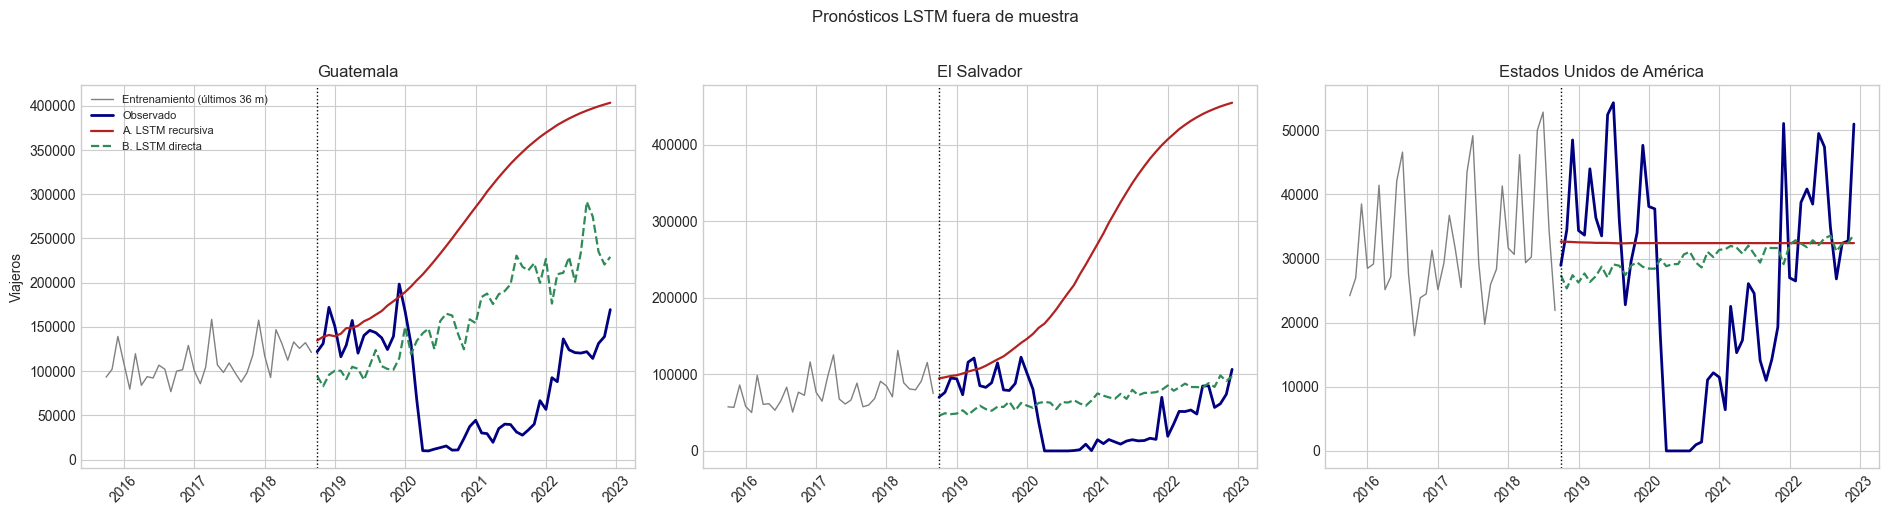

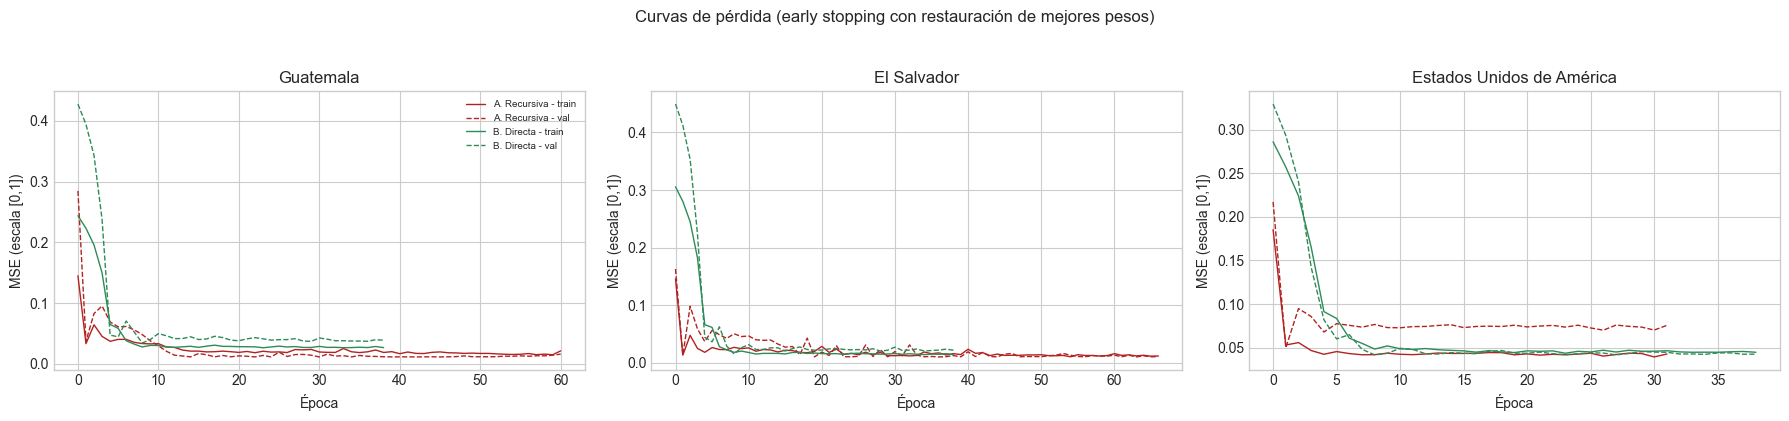

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (pais, (train, test)) in zip(axes, divisiones.items()):
    ax.plot(train.iloc[-36:], color="gray", lw=1, label="Entrenamiento (últimos 36 m)")
    ax.plot(test, color="navy", lw=2, label="Observado")
    ax.plot(resultados_lstm[pais]["A. Recursiva"]["pred"], color="firebrick",
            lw=1.6, label="A. LSTM recursiva")
    ax.plot(resultados_lstm[pais]["B. Directa"]["pred"], color="seagreen",
            lw=1.6, ls="--", label="B. LSTM directa")
    ax.axvline(test.index[0], color="black", ls=":", lw=1)
    ax.set_title(pais)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Viajeros")
axes[0].legend(fontsize=8)
fig.suptitle("Pronósticos LSTM fuera de muestra", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, pais in zip(axes, divisiones):
    for arq, color in [("A. Recursiva", "firebrick"), ("B. Directa", "seagreen")]:
        h = resultados_lstm[pais][arq]["historia"].history
        ax.plot(h["loss"], color=color, lw=1, label=f"{arq} - train")
        ax.plot(h["val_loss"], color=color, lw=1, ls="--", label=f"{arq} - val")
    ax.set_title(pais); ax.set_xlabel("Época"); ax.set_ylabel("MSE (escala [0,1])")
axes[0].legend(fontsize=7)
fig.suptitle("Curvas de pérdida (early stopping con restauración de mejores pesos)", y=1.04)
plt.tight_layout()
plt.show()

## 1.3-1.4. Comparación contra los modelos del Laboratorio 1

Los valores de referencia son los mejores modelos por RMSE obtenidos en
el Laboratorio 1 sobre **exactamente la misma partición**. Se agrega
`Seasonal naïve` recalculado aquí como piso de comparación: cualquier
modelo que no lo supere no aporta valor predictivo.

In [12]:
# Mejores modelos del Laboratorio 1 (misma partición 70/30)
baseline_lab1 = {
    "Guatemala": ("Suavizamiento exponencial", 51_965, 66_129),
    "El Salvador": ("ARIMA(4, 1, 3)", 42_141, 53_001),
    "Estados Unidos de América": ("ARIMA(2, 1, 4)", 13_458, 16_746),
}

filas_final = []
for pais, (train, test) in divisiones.items():
    snaive = pd.Series(np.resize(train.iloc[-12:].to_numpy(), len(test)), index=test.index)
    m_sn = metricas(test.to_numpy(), snaive)
    nombre_l1, mae_l1, rmse_l1 = baseline_lab1[pais]

    filas_final += [
        {"Serie": pais, "Origen": "Lab 1", "Modelo": nombre_l1, "MAE": mae_l1, "RMSE": rmse_l1},
        {"Serie": pais, "Origen": "Referencia", "Modelo": "Seasonal naïve", **m_sn},
    ]
    for arq in ["A. Recursiva", "B. Directa"]:
        r = resultados_lstm[pais][arq]
        filas_final.append({"Serie": pais, "Origen": "Lab 2",
                            "Modelo": f"LSTM {arq}", "MAE": r["MAE"], "RMSE": r["RMSE"]})

tabla_final = pd.DataFrame(filas_final)
tabla_final["Δ RMSE vs Lab 1 (%)"] = tabla_final.apply(
    lambda f: 100 * (f["RMSE"] / baseline_lab1[f["Serie"]][2] - 1), axis=1
)
tabla_final = tabla_final.sort_values(["Serie", "RMSE"]).reset_index(drop=True)
display(tabla_final.style.format({
    "MAE": "{:,.0f}", "RMSE": "{:,.0f}", "Δ RMSE vs Lab 1 (%)": "{:+.1f}%"
}))

,Serie,Origen,Modelo,MAE,RMSE,Δ RMSE vs Lab 1 (%)
0,El Salvador,Lab 2,LSTM B. Directa,"43,830","47,997",-9.4%
1,El Salvador,Lab 1,"ARIMA(4, 1, 3)","42,141","53,001",+0.0%
2,El Salvador,Referencia,Seasonal naïve,"43,234","55,242",+4.2%
3,El Salvador,Lab 2,LSTM A. Recursiva,"212,217","257,431",+385.7%
4,Estados Unidos de América,Lab 2,LSTM B. Directa,"13,896","16,618",-0.8%
5,Estados Unidos de América,Lab 1,"ARIMA(2, 1, 4)","13,458","16,746",+0.0%
6,Estados Unidos de América,Lab 2,LSTM A. Recursiva,"13,553","16,903",+0.9%
7,Estados Unidos de América,Referencia,Seasonal naïve,"13,012","17,847",+6.6%
8,Guatemala,Lab 1,Suavizamiento exponencial,"51,965","66,129",+0.0%
9,Guatemala,Referencia,Seasonal naïve,"53,779","67,335",+1.8%


In [13]:
print("LECTURA DE RESULTADOS — LSTM vs LABORATORIO 1")
for pais, (train, test) in divisiones.items():
    sub = tabla_final[tabla_final["Serie"] == pais]
    ganador = sub.iloc[0]
    a = resultados_lstm[pais]["A. Recursiva"]
    b = resultados_lstm[pais]["B. Directa"]
    mejor_lstm = "A. Recursiva" if a["RMSE"] <= b["RMSE"] else "B. Directa"
    peor_lstm = "B. Directa" if mejor_lstm == "A. Recursiva" else "A. Recursiva"
    nombre_l1, _, rmse_l1 = baseline_lab1[pais]
    delta = 100 * (resultados_lstm[pais][mejor_lstm]["RMSE"] / rmse_l1 - 1)

    print(f"\n{pais}  (n_train={len(train)}, n_test={len(test)}, "
          f"promedio de prueba={test.mean():,.0f})")
    print(f"- Mejor LSTM: {mejor_lstm} — RMSE={resultados_lstm[pais][mejor_lstm]['RMSE']:,.0f}, "
          f"MAE={resultados_lstm[pais][mejor_lstm]['MAE']:,.0f}.")
    print(f"  Configuración: {etiqueta(resultados_lstm[pais][mejor_lstm]['config'])}.")
    print(f"- La otra arquitectura ({peor_lstm}) obtuvo "
          f"RMSE={resultados_lstm[pais][peor_lstm]['RMSE']:,.0f}.")
    print(f"- Referencia Lab 1 ({nombre_l1}): RMSE={rmse_l1:,.0f}. "
          f"La mejor LSTM queda {delta:+.1f}% respecto de ese RMSE "
          f"({'peor' if delta > 0 else 'mejor'}).")
    print(f"- Modelo con menor RMSE global de la serie: {ganador['Modelo']} "
          f"({ganador['Origen']}), RMSE={ganador['RMSE']:,.0f}.")

print("\nCRITERIO DE COMPARACIÓN")
print("- RMSE fuera de muestra como criterio principal (penaliza los errores "
      "grandes del período 2020, que es donde estos modelos se separan).")
print("- MAE como evidencia complementaria: es menos sensible al choque y "
      "describe mejor el error típico mes a mes.")
print("- No se usan AIC/BIC: no son comparables entre una red neuronal y un "
      "ARIMA porque no comparten verosimilitud ni definición de parámetros.")
print("- Todos los modelos comparten partición, transformación log1p y "
      "escala de reporte (viajeros), por lo que las cifras son comparables.")

LECTURA DE RESULTADOS — LSTM vs LABORATORIO 1

Guatemala  (n_train=117, n_test=51, promedio de prueba=88,013)
- Mejor LSTM: B. Directa — RMSE=114,690, MAE=100,719.
  Configuración: directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005.
- La otra arquitectura (A. Recursiva) obtuvo RMSE=217,450.
- Referencia Lab 1 (Suavizamiento exponencial): RMSE=66,129. La mejor LSTM queda +73.4% respecto de ese RMSE (peor).
- Modelo con menor RMSE global de la serie: Suavizamiento exponencial (Lab 1), RMSE=66,129.

El Salvador  (n_train=117, n_test=51, promedio de prueba=50,298)
- Mejor LSTM: B. Directa — RMSE=47,997, MAE=43,830.
  Configuración: directa|lb=12|u=128|capas=1|drop=0.2|lr=0.0005.
- La otra arquitectura (A. Recursiva) obtuvo RMSE=257,431.
- Referencia Lab 1 (ARIMA(4, 1, 3)): RMSE=53,001. La mejor LSTM queda -9.4% respecto de ese RMSE (mejor).
- Modelo con menor RMSE global de la serie: LSTM B. Directa (Lab 2), RMSE=47,997.

Estados Unidos de América  (n_train=117, n_test=51, promedio de prueba=2

## Discusión (1.4)

### Respuestas directas

**¿Cuál predijo mejor entre las dos LSTM?** El Modelo B (directa
multi-horizonte) en las tres series: RMSE de 114,690 vs 217,450 en
Guatemala, 47,997 vs 257,431 en El Salvador y 16,618 vs 16,903 en
Estados Unidos. La ventaja es abrumadora en las dos series con colapso
severo en 2020 y marginal en Estados Unidos.

**¿Son mejores que los modelos del Laboratorio 1?** Solo parcialmente.
El Salvador es el único caso con mejora apreciable en RMSE (47,997 frente
a 53,001 del ARIMA(4,1,3), −9.4%). Estados Unidos es un empate técnico
(−0.8%, dentro del ruido entre semillas). Guatemala es una derrota clara:
114,690 frente a 66,129 del suavizamiento exponencial (+73.4%).

**¿Cómo lo determinamos?** RMSE fuera de muestra como criterio principal
y MAE como evidencia complementaria, sobre la misma partición 70/30, la
misma transformación `log1p` y la misma escala de reporte (viajeros). No
se usan AIC/BIC entre familias porque una red neuronal y un ARIMA no
comparten verosimilitud ni definición de parámetros.

---

### Diagnóstico del fallo: dos causas independientes

Los errores observados no tienen un solo origen. Conviene separarlos
porque explican fenómenos distintos.

#### Causa 1: el cambio estructural de 2020 — explica por qué fallaron *todos*

El entrenamiento termina en **septiembre de 2018** y el conjunto de
prueba cubre octubre 2018 - diciembre 2022. En medio ocurre el cierre de
fronteras: Guatemala pasa de un máximo cercano a 190,000 viajeros
mensuales a valores prácticamente nulos durante 2020.

Los nueve años de entrenamiento (2009-2018) no contienen ningún episodio
comparable. Se le está pidiendo a los modelos que anticipen un evento
cuya información no existe en los datos con los que fueron ajustados.
**Ningún modelo puede hacerlo**, ni clásico ni neuronal, y por eso todos
los RMSE se sitúan entre 62% y 130% del promedio del período de prueba.
Esta causa explica la magnitud general del error, pero no explica el
comportamiento del Modelo A.

#### Causa 2: la realimentación recursiva — explica el error desproporcionado del Modelo A

El Modelo A predice un mes a la vez y reinyecta su propia salida como
entrada del paso siguiente:

    mes  1: ventana de 12 meses reales          → predice ~132,000
    mes  2: 11 reales + 1 predicción propia     → predice ~135,000
    mes  3: 10 reales + 2 predicciones propias  → predice ~138,000
    ...
    mes 13: 0 reales + 12 predicciones propias
    ...
    mes 51: exclusivamente predicciones propias → predice ~405,000

A partir del mes 13 el modelo ya no observa **ningún dato real**: opera
enteramente sobre su propia salida. Como aprendió de 2009-2018 que la
serie crece de forma sostenida, aplica ese sesgo de crecimiento 51 veces
consecutivas. Con un sesgo aproximado de 2.2% mensual:

    1.022^51 ≈ 3.0   →   130,000 × 3.0 ≈ 400,000

Es el mecanismo del interés compuesto: un error diminuto por paso, si se
repite, deja de ser diminuto. El efecto se amplifica porque el modelado
ocurre en escala logarítmica y la inversión con `expm1` convierte una
deriva lineal en `log` en un crecimiento exponencial en viajeros.

El resultado es la peor combinación posible: la realidad se desplomó
hacia cero mientras el pronóstico ascendía hacia 400,000 (Guatemala) y
460,000 (El Salvador). De ahí los RMSE de 217,450 y 257,431.

#### Por qué el Modelo B resistió mejor

El Modelo B emite los 51 pasos en una sola pasada (`Dense(51)`) y nunca
consume sus propias predicciones, de modo que la acumulación de error no
puede ocurrir por construcción. No es un modelo "más inteligente": su
pronóstico es esencialmente una trayectoria suave y conservadora. Su
ventaja no consiste en acertar, sino en equivocarse sin escalar.

#### Por qué ganó el suavizamiento exponencial en Guatemala

El SES pronostica una línea plana en el último nivel observado
(~130,000). Frente a una realidad que oscila entre 10,000 y 190,000, esa
línea plana está equivocada, pero mucho menos que una rampa hacia
400,000. **El modelo ganador es el que asumió menos.** Cuando el futuro
contiene un régimen ausente del entrenamiento, no extrapolar tendencia es
una estrategia superior a extrapolarla.

---

### Hallazgos

**1. El criterio de selección se invirtió entre validación y prueba.**
En Guatemala y El Salvador la validación interna prefirió el Modelo A
(RMSE_val de 23,388 y 25,804) sobre el B (35,488 y 32,791), pero en
prueba el orden se invierte por factores de 2x y 5x. La causa es
estructural: la validación son los últimos 24 meses del entrenamiento
(2016-10 a 2018-09), un período estable y con la mitad del horizonte de
prueba. Un esquema de selección que no contiene el cambio de régimen que
debe anticipar, ni la longitud de horizonte donde el error se acumula,
elige el modelo equivocado. Estados Unidos, la única serie donde
validación y prueba coinciden, es también la única cuyo período de prueba
no está dominado por un colapso a valores cercanos a cero.

**2. La LSTM intercambia error típico por robustez de cola.** En las dos
series donde compite, mejora el RMSE pero empeora el MAE respecto del
Laboratorio 1: El Salvador 47,997/43,830 frente a 53,001/42,141; Estados
Unidos 16,618/13,896 frente a 16,746/13,458. Comete menos errores
catastróficos y algo más de error mes a mes. El patrón es consistente en
dos series independientes.

**3. Ningún modelo supera con claridad al piso ingenuo.** Seasonal naïve
obtiene 67,335, 55,242 y 17,847. El ganador de Guatemala lo supera por
1.8% y el de Estados Unidos por 6.6%. Únicamente el Modelo B en El
Salvador lo supera por un margen apreciable (13%) y, con dos semillas y
una desviación entre ellas de aproximadamente 1,400, esa ventaja no está
claramente fuera del ruido de inicialización. En esta partición ningún
modelo, clásico o neuronal, es utilizable para planificación.

**4. La complejidad no compensa el tamaño de muestra.** Con 117 meses de
entrenamiento y `lookback = 12` quedan ~105 ventanas. La red ajusta
miles de parámetros contra los 2-7 de un ARIMA: un régimen de varianza
alta que queda documentado en la columna `RMSE_sd` del tuneo.

---

### Limitaciones declaradas

1. El Modelo B se construye con `Dense(51)`, es decir con el horizonte de
   prueba incorporado en la arquitectura. Es legítimo porque el horizonte
   se conoce de antemano, pero implica que está optimizado para esa
   longitud específica y no transfiere a otras.
2. El tuneo se realizó con horizonte de validación de 24 meses y el
   despliegue con 51. Esa asimetría perjudicó al Modelo A, cuyo error se
   acumula con el horizonte, y favoreció al B. En ningún caso la
   selección ocurrió bajo condiciones representativas de la prueba.
3. Dos semillas por configuración acotan, pero no eliminan, el efecto de
   la inicialización aleatoria.
4. El pronóstico recursivo no se acotó al rango histórico observado. Se
   conservó así de forma deliberada para documentar la deriva; acotarlo
   en `[0, 1]` en escala MinMax habría limitado el pronóstico al máximo
   de entrenamiento sin alterar el orden de los modelos.